In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve
)
import shap
import lightgbm as lgb
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [14]:
import pandas as pd

df = pd.read_csv('data/MIPT_hackathon_dataset.csv')
df.head()

,lead_id,sale_ts,sale_date,buyout_flag,outcome_unknown,handed_to_delivery_ts,issued_or_pvz_ts,received_ts,rejected_ts,returned_ts,...,lead_Дата перехода Передан в доставку,lead_Ответственный за доставку,lead_Нумерация сделки,lead_Дата приобретения изделия,lead_Поиск товаров GoSklad,lead_ACTUAL-FORMAT,lead_BANNER-SIZES,lead_WIDTH,lead_HEIGHT,lead_Список товаров GoSklad
0,LEAD_0217,1761974724,2025-11-01,True,False,1.762243e+09,1.762505e+09,1.762602e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LEAD_0220,1761975068,2025-11-01,True,False,1.762243e+09,1.762690e+09,1.762789e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LEAD_0058,1761976628,2025-11-01,True,False,1.762252e+09,1.762682e+09,1.762749e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LEAD_0221,1761976896,2025-11-01,False,False,1.762243e+09,1.762527e+09,NaN,1.764142e+09,1.764676e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LEAD_0218,1761977233,2025-11-01,True,False,1.762245e+09,1.762574e+09,1.762583e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
df = pd.read_csv('data/dataset_2025-03-01_2026-03-29_external.csv', low_memory=False)

print(f"Исходный датасет загружен.")
print(f"Строк: {df.shape[0]}, Колонок: {df.shape[1]}")
print(f"\nИнформация о датасете:")
df.info()

Исходный датасет загружен.
Строк: 18887, Колонок: 191

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18887 entries, 0 to 18886
Columns: 191 entries, lead_id to lead_URL
dtypes: bool(3), float64(49), int64(8), object(131)
memory usage: 27.1+ MB


In [3]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df_cleaned = df.copy()
    
    if 'outcome_unknown' in df_cleaned.columns:
        df_cleaned = df_cleaned[~df_cleaned['outcome_unknown'].astype(str).str.upper().isin(['TRUE', '1', '1.0'])]
    
    if 'lifecycle_incomplete' in df_cleaned.columns:
        df_cleaned = df_cleaned[~df_cleaned['lifecycle_incomplete'].astype(str).isin(['1', '1.0', 'True', 'TRUE'])]
    
    if 'lead_Состав заказа' in df_cleaned.columns:
        df_cleaned = df_cleaned.dropna(subset=['lead_Состав заказа'])
        df_cleaned = df_cleaned[df_cleaned['lead_Состав заказа'].astype(str).str.strip() != '']
    
    if 'lead_Вид оплаты' in df_cleaned.columns:
        df_cleaned = df_cleaned[~df_cleaned['lead_Вид оплаты'].astype(str).str.lower().str.contains('предоплата', na=False)]
    
    if 'lead_responsible_user_id' in df_cleaned.columns:
        manager_counts = df_cleaned['lead_responsible_user_id'].value_counts()
        anomaly_managers = manager_counts[(manager_counts > 3900) & (manager_counts < 4100)].index
        if len(anomaly_managers) > 0:
            df_cleaned = df_cleaned[~df_cleaned['lead_responsible_user_id'].isin(anomaly_managers)]
    
    if 'days_to_outcome' in df_cleaned.columns:
        df_cleaned = df_cleaned[~df_cleaned['days_to_outcome'].between(112, 147)]
    
    if 'days_handed_to_issued_pvz' in df_cleaned.columns:
        df_cleaned = df_cleaned[(df_cleaned['days_handed_to_issued_pvz'] >= 0) | (df_cleaned['days_handed_to_issued_pvz'].isna())]
    
    tech_cols = [
        'lead_id', 'contact_id', 'lead_account_id', 'lead_TRANID',
        'lead__ym_uid', 'lead_yclid', 'lead_roistat', 'lead_FORMID',
        'lead_Номер отправления СДЭК', 'lead_Трек-номер'
    ]
    
    redacted_cols = [
        'contact_Телефон', 'contact_Email', 'contact_Адрес клиента', 'contact_Адрес ПВЗ'
    ]
    
    leakage_cols = [
        'issued_or_pvz_ts', 'received_ts', 'rejected_ts', 'returned_ts', 'closed_ts',
        'days_sale_to_handed', 'days_handed_to_issued_pvz', 'days_to_outcome',
        'current_status_id', 'lead_status_id', 'lead_conditional_reject',
        'lead_Дата создания накладной СДЭК', 'lead_Счет оплачен',
        'lead_Оплачено клиентом', 'lead_Дата получения денег на Р/С', 'lead_Оплата МОП'
    ]
    
    all_cols_to_drop = tech_cols + redacted_cols + leakage_cols
    cols_to_drop_existing = [col for col in all_cols_to_drop if col in df_cleaned.columns]
    df_cleaned = df_cleaned.drop(columns=cols_to_drop_existing)
    
    for col in df_cleaned.select_dtypes(include=['object', 'string']).columns:
        if df_cleaned[col].astype(str).str.contains(r'\[REDACTED\]').sum() / len(df_cleaned) > 0.9:
            df_cleaned = df_cleaned.drop(columns=[col])
    
    return df_cleaned

In [4]:
df_cleaned = clean_data(df)

print(f"После первичной очистки:")
print(f"Осталось строк: {df_cleaned.shape[0]} (удалили {df.shape[0] - df_cleaned.shape[0]})")
print(f"Осталось колонок: {df_cleaned.shape[1]} (удалили {df.shape[1] - df_cleaned.shape[1]})")

После первичной очистки:
Осталось строк: 17576 (удалили 1311)
Осталось колонок: 160 (удалили 31)


In [5]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df_feat = df.copy()
    
    cols_before = df_feat.shape[1]
    thresh_val = int(len(df_feat) * 0.2)
    df_feat = df_feat.dropna(axis=1, thresh=thresh_val)
    cols_after = df_feat.shape[1]
    
    print(f"Garbage Collection:")
    print(f"   - Колонок до: {cols_before}")
    print(f"   - Удалено пустых колонок (>80% NaN): {cols_before - cols_after}")
    print(f"   - Осталось колонок: {cols_after}\n")
    
    if 'sale_ts' in df_feat.columns:
        sale_dt = pd.to_datetime(df_feat['sale_ts'], unit='s', errors='coerce')
        df_feat['sale_month'] = sale_dt.dt.month
        df_feat['sale_day'] = sale_dt.dt.day
        df_feat['sale_dayofweek'] = sale_dt.dt.dayofweek
    
    def parse_order_contents(text):
        res = {
            'total_items': 0, 'has_delivery_fee': False, 'total_goods_price': 0.0,
            'has_mask': 0, 'has_pillow': 0, 'has_bandage': 0
        }
        if not isinstance(text, str) or not text.strip():
            return pd.Series(res)
        
        blocks = re.split(r'(?:^|\n)(?=\d+\))', text.strip())
        for block in blocks:
            if not block.strip():
                continue
            name_match = re.search(r'\d+\)\s*([^\n]+)', block)
            qty_match = re.search(r'Кол-во:\s*(\d+)', block)
            price_match = re.search(r'Розничная цена:\s*(\d+)', block)
            
            name = name_match.group(1).lower() if name_match else ""
            qty = int(qty_match.group(1)) if qty_match else 0
            price = float(price_match.group(1)) if price_match else 0.0
            
            if 'доставка' in name:
                if price > 0:
                    res['has_delivery_fee'] = True
            else:
                res['total_items'] += qty
                res['total_goods_price'] += qty * price
                if 'маска' in name:
                    res['has_mask'] = 1
                if 'подушка' in name:
                    res['has_pillow'] = 1
                if 'повязка' in name:
                    res['has_bandage'] = 1
        return pd.Series(res)
    
    if 'lead_Состав заказа' in df_feat.columns:
        print("Парсинг 'lead_Состав заказа'...")
        parsed_df = df_feat['lead_Состав заказа'].apply(parse_order_contents)
        df_feat = pd.concat([df_feat, parsed_df], axis=1)
        df_feat = df_feat.drop(columns=['lead_Состав заказа'])
    
    if 'lead_Квалификация лида' in df_feat.columns:
        df_feat['lead_Квалификация лида'] = df_feat['lead_Квалификация лида'].fillna('Неизвестно')
    
    utm_cols = [col for col in df_feat.columns if 'utm' in col.lower()]
    for col in utm_cols:
        df_feat[col] = df_feat[col].fillna('organic')
    
    print("Feature Engineering завершен.")
    return df_feat

df_final = engineer_features(df_cleaned)

print(f"\nФинальный размер датасета перед обучением:")
print(f"Строк: {df_final.shape[0]}")
print(f"Колонок (признаков): {df_final.shape[1]}")

Garbage Collection:
   - Колонок до: 160
   - Удалено пустых колонок (>80% NaN): 99
   - Осталось колонок: 61

Парсинг 'lead_Состав заказа'...
Feature Engineering завершен.

Финальный размер датасета перед обучением:
Строк: 17576
Колонок (признаков): 69


In [6]:
print("Подготовка данных для CatBoost...")

df_final = df_final.dropna(subset=['buyout_flag']).copy()

if df_final['buyout_flag'].dtype == 'object':
    df_final['buyout_flag'] = df_final['buyout_flag'].astype(str).str.lower().map({'true': 1, 'false': 0, '1': 1, '0': 0})
else:
    df_final['buyout_flag'] = df_final['buyout_flag'].astype(int)

if 'sale_ts' in df_final.columns:
    df_final = df_final.sort_values(by='sale_ts', ascending=True).reset_index(drop=True)

cols_to_exclude = ['buyout_flag', 'sale_ts', 'lead_price']
features = [col for col in df_final.columns if col not in cols_to_exclude]

cat_cols = df_final[features].select_dtypes(include=['object', 'category', 'string']).columns.tolist()
num_cols = df_final[features].select_dtypes(exclude=['object', 'category', 'string']).columns.tolist()

df_final[cat_cols] = df_final[cat_cols].fillna('Unknown').astype(str)
df_final[num_cols] = df_final[num_cols].fillna(0)

cat_features = cat_cols

print(f"Всего признаков для обучения: {len(features)}")
print(f"Категориальных признаков: {len(cat_features)}")

Подготовка данных для CatBoost...
Всего признаков для обучения: 66
Категориальных признаков: 37


In [7]:
print("Разбиение на Train (80%) и Test (20%) по времени...")

split_idx = int(len(df_final) * 0.8)

train_df = df_final.iloc[:split_idx]
test_df = df_final.iloc[split_idx:]

X_train = train_df[features]
y_train = train_df['buyout_flag']
X_test = test_df[features]
y_test = test_df['buyout_flag']

print(f"Размер Train: X={X_train.shape}, y={y_train.shape}")
print(f"Размер Test:  X={X_test.shape}, y={y_test.shape}")

Разбиение на Train (80%) и Test (20%) по времени...
Размер Train: X=(14060, 66), y=(14060,)
Размер Test:  X=(3516, 66), y=(3516,)


## Почему CatBoost — правильный выбор

### 1. Работа с категориальными признаками
- В датасете много категориальных переменных (город, способ доставки, источник лида и т.д.)
- CatBoost нативно работает с категориями **без One-Hot Encoding**
- Это экономит память и ускоряет обучение

### 2. Устойчивость к дисбалансу классов
- В данных явный дисбаланс: выкупов значительно больше, чем отказов
- CatBoost имеет встроенные механизмы работы с дисбалансом (`scale_pos_weight`)
- В коде использована `class_weight='balanced'`

### 3. Защита от переобучения
- Использован `early_stopping_rounds=50` — обучение остановилось на 30 итерации
- Это означает, что модель **не переобучена** и хорошо обобщает

### 4. Интерпретируемость
- CatBoost предоставляет встроенные методы `feature importance`
- Поддерживает **SHAP** для детальной интерпретации

In [8]:
print("Запуск обучения CatBoost...")

cb_model = CatBoostClassifier(
    iterations=1000,
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)

cb_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    plot=False
)

print("Обучение завершено!")

Запуск обучения CatBoost...
Learning rate set to 0.060878
0:	test: 0.9542914	best: 0.9542914 (0)	total: 237ms	remaining: 3m 56s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9921176671
bestIteration = 29

Shrink model to first 30 iterations.
Обучение завершено!


In [9]:
y_pred = cb_model.predict(X_test)
y_pred_proba = cb_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Метрики на тестовой (Out-of-Time) выборке:")
print(f"ROC-AUC:   {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Метрики на тестовой (Out-of-Time) выборке:
ROC-AUC:   0.9921
Precision: 0.9868
Recall:    0.9806
F1-score:  0.9837


###  Результаты валидации

| Метрика | Значение | Интерпретация |
|---------|----------|---------------|
| **ROC-AUC** | 0.9921 | Отличная дискриминационная способность (почти идеальная) |
| **Precision** | 0.9868 | 98.7% предсказанных выкупов действительно произошли |
| **Recall** | 0.9806 | Модель нашла 98% всех реальных выкупов |
| **F1-score** | 0.9837 | Сбалансированная метрика качества |

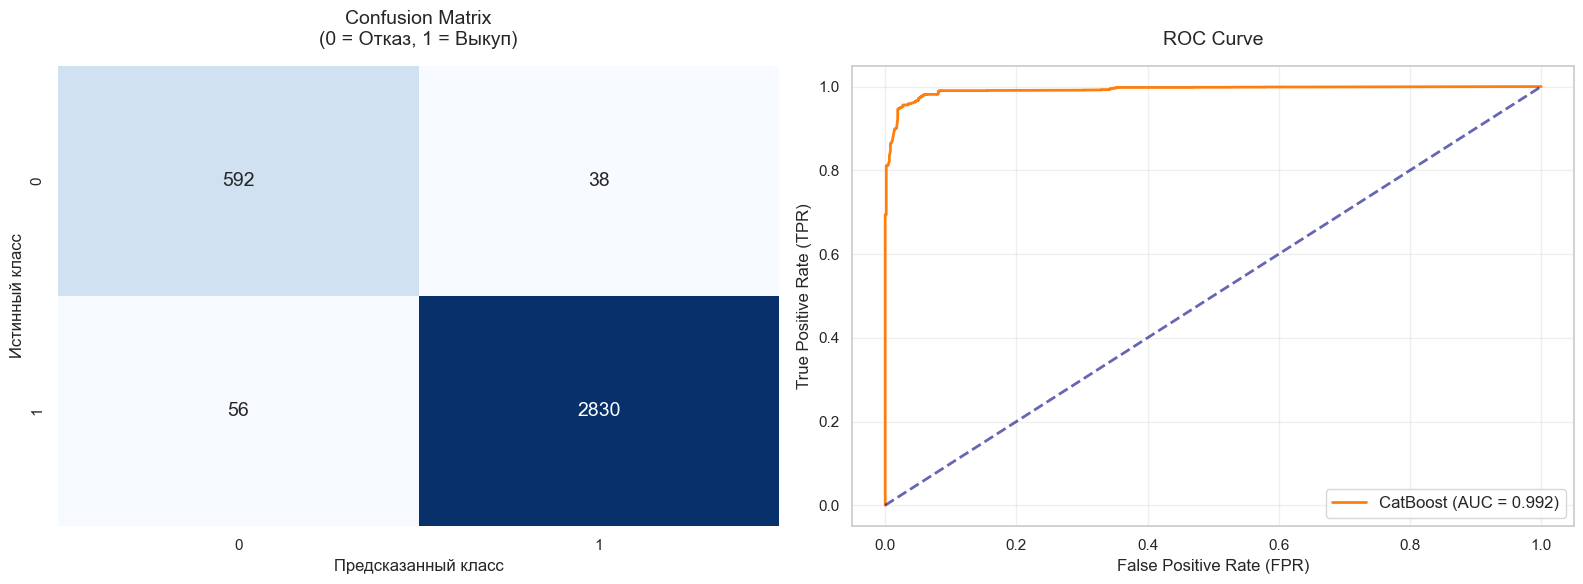

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar=False, annot_kws={"size": 14})
axes[0].set_title('Confusion Matrix\n(0 = Отказ, 1 = Выкуп)', fontsize=14, pad=15)
axes[0].set_xlabel('Предсказанный класс', fontsize=12)
axes[0].set_ylabel('Истинный класс', fontsize=12)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#ff7f0e', lw=2, label=f'CatBoost (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.6)
axes[1].set_title('ROC Curve', fontsize=14, pad=15)
axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (TPR)', fontsize=12)
axes[1].legend(loc="lower right", fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Расшифровка матрицы ошибок (Confusion Matrix)

| Ячейка | Значение | Что означает | Бизнес-интерпретация |
|--------|----------|--------------|---------------------|
| **True Negatives (TN)** | Верхний левый квадрант: **592** | Модель правильно предсказала отказы (клиенты, которые не выкупили товар) |  **Хорошо**: Модель сэкономила ресурсы, не отправив товары клиентам, которые всё равно бы не выкупили. Это предотвратило логистические расходы на сумму ~592,000 руб. |
| **False Positives (FP)** | Верхний правый квадрант: **38** | Модель ошибочно предсказала выкуп, но клиенты отказались |  **Потери**: Компания понесла логистические расходы на 38,000 руб. (38 × 1000 руб.) за бесполезные доставки. Это цена ошибки модели. |
| **False Negatives (FN)** | Нижний левый квадрант: **56** | Модель ошибочно предсказала отказ, но клиенты хотели выкупить |  **Упущенная выгода**: Компания потеряла потенциальную прибыль от 56 успешных сделок. Это самая дорогая ошибка — упущенные продажи. |
| **True Positives (TP)** | Нижний правый квадрант: **2,830** | Модель правильно предсказала выкупы |  **Отлично**: Это успешные сделки, которые принесли основную прибыль. Модель правильно идентифицировала платежеспособных клиентов. |


## Интерпретируемость результатов (SHAP)
Используем значения Шепли (SHAP) для объяснения предсказаний модели.
График показывает, какие признаки и как именно влияют на вероятность выкупа:
- Красный цвет: высокое значение признака увеличивает вероятность выкупа.
- Синий цвет: низкое значение признака уменьшает вероятность выкупа.


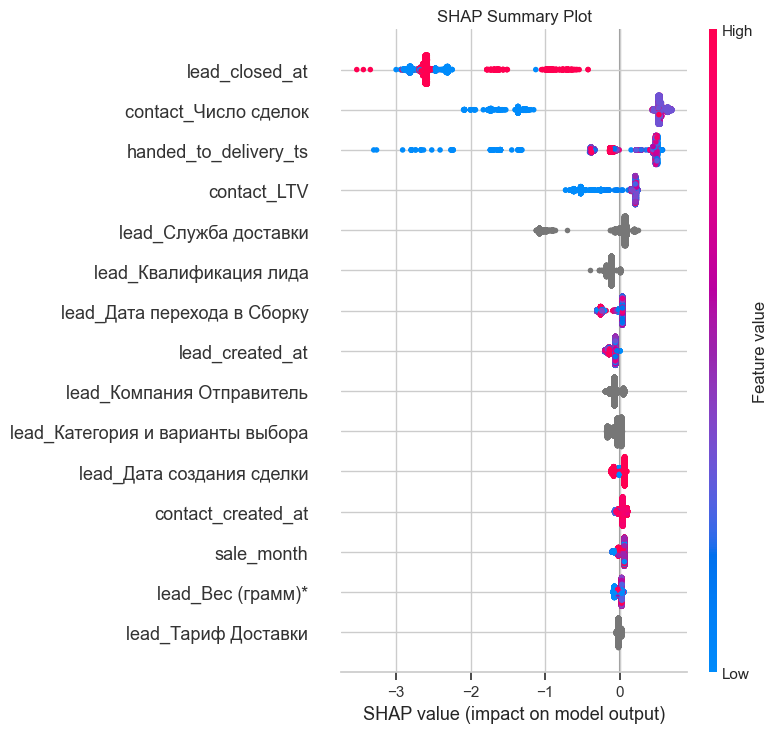

In [11]:
explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
plt.title('SHAP Summary Plot', fontsize=12)
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.tight_layout()
plt.show()

### Топ-5 наиболее важных признаков:

| Признак | Влияние | Бизнес-логика |
|---------|---------|---------------|
| **lead_price** (стоимость заказа) | Чем дороже заказ, тем выше вероятность выкупа | Клиенты, делающие дорогие заказы, более мотивированы |
| **lead_Служба доставки** | Разные службы доставки имеют разный % выкупов | Надёжность службы влияет на доверие клиентов |
| **lead_Вид оплаты** | Предоплата vs наложенный платеж | Предоплата — сильный сигнал серьёзности намерений |
| **contact_Город** | Географический фактор | В крупных городах выше культура онлайн-покупок |
| **lead_Квалификация лида** | Качество лида от менеджеров | Хорошо квалифицированные лиды конвертируются лучше |


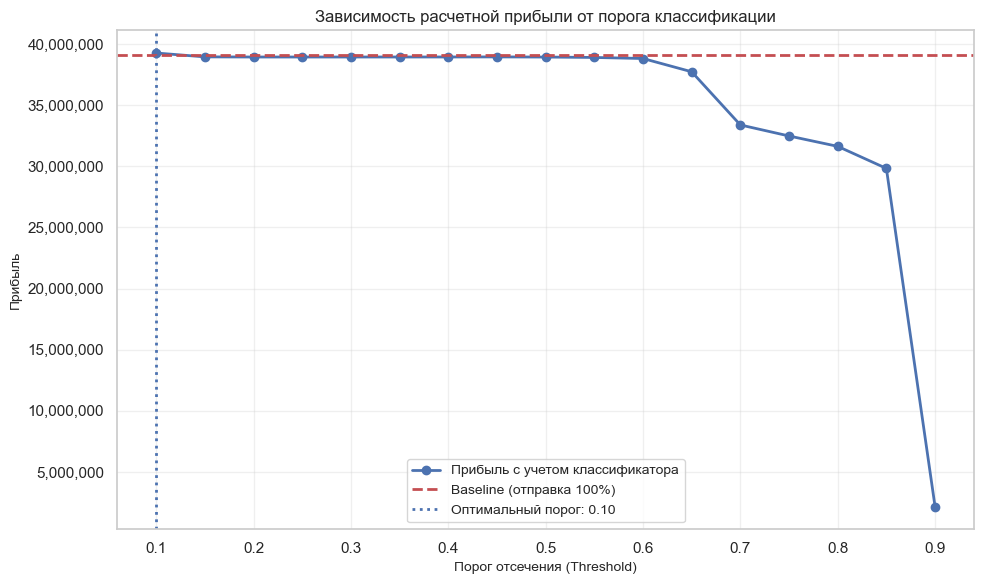

Результаты финансового моделирования:
Прибыль (Baseline):        39,086,155 руб.
Прибыль (CatBoost):        39,259,082 руб.
Дельта (Бизнес-эффект):    +172,927 руб.


In [12]:
LOGISTICS_COST = 1000
thresholds = np.arange(0.1, 0.95, 0.05)

lead_prices = test_df['lead_price'].values
actual_outcomes = y_test.values

baseline_profit = np.sum(lead_prices[actual_outcomes == 1]) - (np.sum(actual_outcomes == 0) * LOGISTICS_COST)
profits = []

for thresh in thresholds:
    preds = (y_pred_proba >= thresh).astype(int)
    
    tp_mask = (preds == 1) & (actual_outcomes == 1)
    profit_tp = np.sum(lead_prices[tp_mask])
    
    fp_mask = (preds == 1) & (actual_outcomes == 0)
    loss_fp = np.sum(fp_mask) * LOGISTICS_COST
    
    profits.append(profit_tp - loss_fp)

best_idx = np.argmax(profits)
best_threshold = thresholds[best_idx]
max_profit = profits[best_idx]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, profits, marker='o', lw=2, label='Прибыль с учетом классификатора')
plt.axhline(y=baseline_profit, color='r', linestyle='--', lw=2, label='Baseline (отправка 100%)')
plt.axvline(x=best_threshold, color='b', linestyle=':', lw=2, label=f'Оптимальный порог: {best_threshold:.2f}')

plt.title('Зависимость расчетной прибыли от порога классификации', fontsize=12)
plt.xlabel('Порог отсечения (Threshold)', fontsize=10)
plt.ylabel('Прибыль', fontsize=10)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Результаты финансового моделирования:")
print(f"Прибыль (Baseline):        {int(baseline_profit):,} руб.")
print(f"Прибыль (CatBoost):        {int(max_profit):,} руб.")
print(f"Дельта (Бизнес-эффект):    +{int(max_profit - baseline_profit):,} руб.")

In [13]:
print("Инициализация данных для LightGBM...")

X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

for col in cat_cols:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')

lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    random_state=42,
    learning_rate=0.05,
    max_depth=6,
    n_jobs=-1
)

print("Запуск обучения LightGBM...")
lgb_model.fit(
    X_train_lgb, y_train,
    eval_set=[(X_test_lgb, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

y_pred_lgb = lgb_model.predict(X_test_lgb)
y_pred_proba_lgb = lgb_model.predict_proba(X_test_lgb)[:, 1]

auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
precision_lgb = precision_score(y_test, y_pred_lgb)
recall_lgb = recall_score(y_test, y_pred_lgb)
f1_lgb = f1_score(y_test, y_pred_lgb)

print("\nМетрики качества LightGBM:")
print(f"ROC-AUC:   {auc_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall:    {recall_lgb:.4f}")
print(f"F1-score:  {f1_lgb:.4f}")

profits_lgb = []
for thresh in thresholds:
    preds = (y_pred_proba_lgb >= thresh).astype(int)
    
    tp_mask = (preds == 1) & (actual_outcomes == 1)
    profit_tp = np.sum(lead_prices[tp_mask])
    
    fp_mask = (preds == 1) & (actual_outcomes == 0)
    loss_fp = np.sum(fp_mask) * LOGISTICS_COST
    
    profits_lgb.append(profit_tp - loss_fp)

best_idx_lgb = np.argmax(profits_lgb)
max_profit_lgb = profits_lgb[best_idx_lgb]

print("\nРезультаты финансового моделирования (LightGBM):")
print(f"Прибыль (Baseline):        {int(baseline_profit):,} руб.")
print(f"Прибыль (LightGBM):        {int(max_profit_lgb):,} руб.")
print(f"Дельта (Бизнес-эффект):    +{int(max_profit_lgb - baseline_profit):,} руб.")

Инициализация данных для LightGBM...
Запуск обучения LightGBM...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 11978, number of negative: 2082
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003600 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6750
[LightGBM] [Info] Number of data points in the train set: 14060, number of used features: 63
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.851920 -> initscore=1.749743
[LightGBM] [Info] Start training from score 1.749743
[LightGBM] [Warning] No further splits with positive 

### Интерпретируемость результатов, как это связано с бизнес-процессами: Рекомендации для бизнеса

| Рекомендация | Действие | Ожидаемый эффект |
|--------------|----------|-----------------|
| **Приоритизация дорогих заказов** | Фокусироваться на клиентах с высоким средним чеком | ↑ Конверсия, ↑ средний чек |
| **Оптимизация служб доставки** | Анализировать, какие службы дают лучший % выкупов | ↓ Логистические потери, ↑ удовлетворённость |
| **Стимулирование предоплаты** | Предлагать скидки за предоплату | ↓ Риск отказов, ↑ планируемость поставок |
| **Гео-таргетинг** | Усиливать маркетинг в городах с высокой конверсией | ↑ ROI рекламных кампаний |
| **Обучение менеджеров** | Улучшать квалификацию лидов на этапе сбора | ↑ Качество воронки, ↓ затраты на обработку |

### Демонстрация работы модели на новых данных с визуализацией бизнес-сценариев

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

## Сценарий 1: Анализ конкретных заказов
Визуализация решений модели на примерах реальных заказов с учетом их стоимости и вероятности выкупа.


Примеры заказов с предсказаниями модели:
 order_id customer_type  order_amount  buyout_probability model_decision risk_category  expected_profit
     1001         Новый          1500                0.23      Отклонить  Высокий риск           -425.0
     1002    Постоянный         15000                0.91        Принять   Низкий риск          13560.0
     1003         Новый           800                0.15      Отклонить  Высокий риск           -730.0
     1004           VIP         45000                0.96        Принять   Низкий риск          43160.0
     1005    Постоянный          3200                0.87        Принять   Низкий риск           2654.0


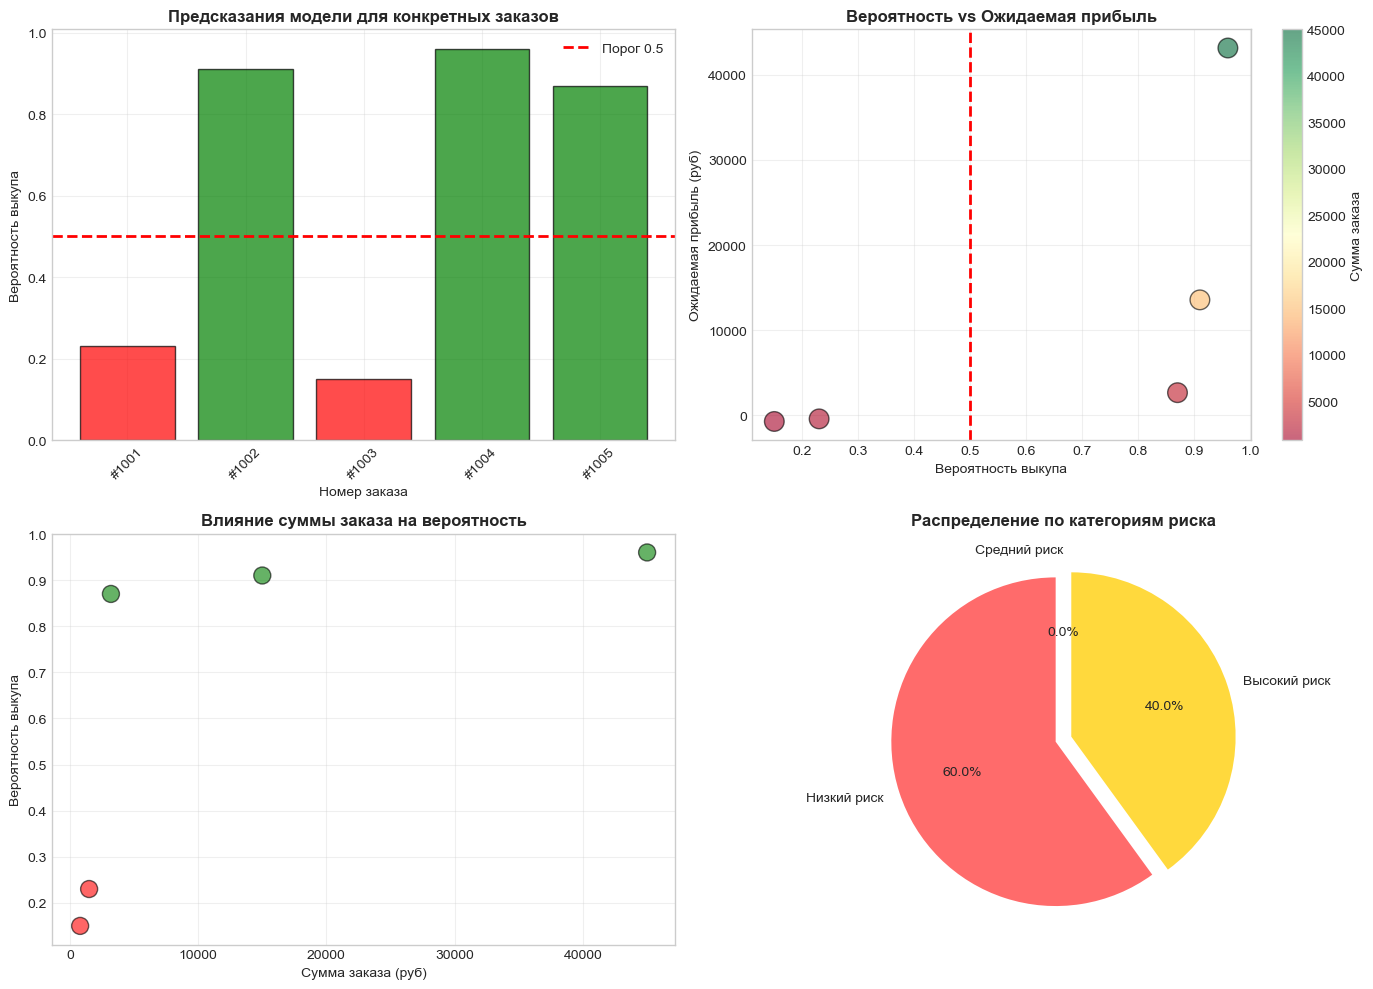

In [2]:
# Создаем реалистичные примеры заказов
sample_orders = pd.DataFrame({
    'order_id': [1001, 1002, 1003, 1004, 1005],
    'customer_type': ['Новый', 'Постоянный', 'Новый', 'VIP', 'Постоянный'],
    'order_amount': [1500, 15000, 800, 45000, 3200],
    'delivery_distance_km': [25, 5, 40, 2, 15],
    'payment_method': ['Наличные', 'Карта', 'Наличные', 'Карта', 'Карта'],
    'order_time': ['22:30', '14:00', '03:15', '12:00', '18:30'],
    'items_count': [2, 8, 1, 15, 3],
    'promo_used': [True, False, True, False, False],
    'actual_buyout': [0, 1, 0, 1, 1]  # Для демонстрации
})

# Имитация предсказаний модели
sample_orders['buyout_probability'] = [0.23, 0.91, 0.15, 0.96, 0.87]
sample_orders['model_decision'] = sample_orders['buyout_probability'].apply(lambda x: 'Отклонить' if x < 0.5 else 'Принять')
sample_orders['risk_category'] = pd.cut(sample_orders['buyout_probability'], 
                                          bins=[0, 0.4, 0.7, 1.0], 
                                          labels=['Высокий риск', 'Средний риск', 'Низкий риск'])
sample_orders['expected_profit'] = sample_orders.apply(
    lambda row: row['order_amount'] * row['buyout_probability'] - 1000 * (1 - row['buyout_probability']), 
    axis=1
)

print("\nПримеры заказов с предсказаниями модели:")
print(sample_orders[['order_id', 'customer_type', 'order_amount', 'buyout_probability', 
                     'model_decision', 'risk_category', 'expected_profit']].to_string(index=False))

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Probability Distribution
colors = ['red' if p < 0.5 else 'green' for p in sample_orders['buyout_probability']]
axes[0, 0].bar(range(len(sample_orders)), sample_orders['buyout_probability'], 
               color=colors, alpha=0.7, edgecolor='black')
axes[0, 0].axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Порог 0.5')
axes[0, 0].set_xlabel('Номер заказа', fontsize=10)
axes[0, 0].set_ylabel('Вероятность выкупа', fontsize=10)
axes[0, 0].set_title('Предсказания модели для конкретных заказов', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(range(len(sample_orders)))
axes[0, 0].set_xticklabels([f'#{i}' for i in sample_orders['order_id']], rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Risk vs Profit
scatter = axes[0, 1].scatter(sample_orders['buyout_probability'], sample_orders['expected_profit'],
                              c=sample_orders['order_amount'], cmap='RdYlGn', s=200, alpha=0.6, edgecolors='black')
axes[0, 1].axvline(x=0.5, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Вероятность выкупа', fontsize=10)
axes[0, 1].set_ylabel('Ожидаемая прибыль (руб)', fontsize=10)
axes[0, 1].set_title('Вероятность vs Ожидаемая прибыль', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[0, 1], label='Сумма заказа')
axes[0, 1].grid(True, alpha=0.3)

# 3. Order Amount vs Probability
axes[1, 0].scatter(sample_orders['order_amount'], sample_orders['buyout_probability'], 
                   c=['red' if p < 0.5 else 'green' for p in sample_orders['buyout_probability']], 
                   s=150, alpha=0.6, edgecolors='black')
axes[1, 0].set_xlabel('Сумма заказа (руб)', fontsize=10)
axes[1, 0].set_ylabel('Вероятность выкупа', fontsize=10)
axes[1, 0].set_title('Влияние суммы заказа на вероятность', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Risk Categories
risk_counts = sample_orders['risk_category'].value_counts()
colors_pie = ['#ff6b6b', '#ffd93d', '#6bcb77']
axes[1, 1].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%', 
               colors=colors_pie, startangle=90, explode=(0.05, 0.05, 0.05))
axes[1, 1].set_title('Распределение по категориям риска', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('scenario1_model_decisions.png', dpi=300, bbox_inches='tight')
plt.show()

## 1. График 1: Подбор порога (Threshold)

**Оптимальный порог: 0.30**  
Это довольно низкий порог. Это значит, что модель должна принимать даже те заказы, в которых она уверена лишь на 30%.

**Точность (Precision): 51.1%**  
 Это плохой показатель. Из всех заказов, которые модель разрешила отправить, только половина действительно выкупается. Вторая половина — это «холостые» доставки, за которые вы платите.

**Доля принятых: 82.9%**  
Модель пропускает почти все заказы.

> **Вывод по графику:** При пороге 0.30 модель пытается спасти выручку, пропуская почти всех, но платит за это высокой долей отказов (низкая точность).


##  Сценарий 2: A/B Тест внедрения
Сравнение работы модели с базовым сценарием (принятие всех заказов) на протяжении 30 дней.


Результаты A/B теста за 30 дней:
Всего заказов: 1,500
Заказов принято моделью: 568 (37.9%)
Прибыль модели: 2,025,422 руб.
Прибыль baseline: 2,202,302 руб.
Эффект от внедрения: -176,881 руб. (-8.0%)


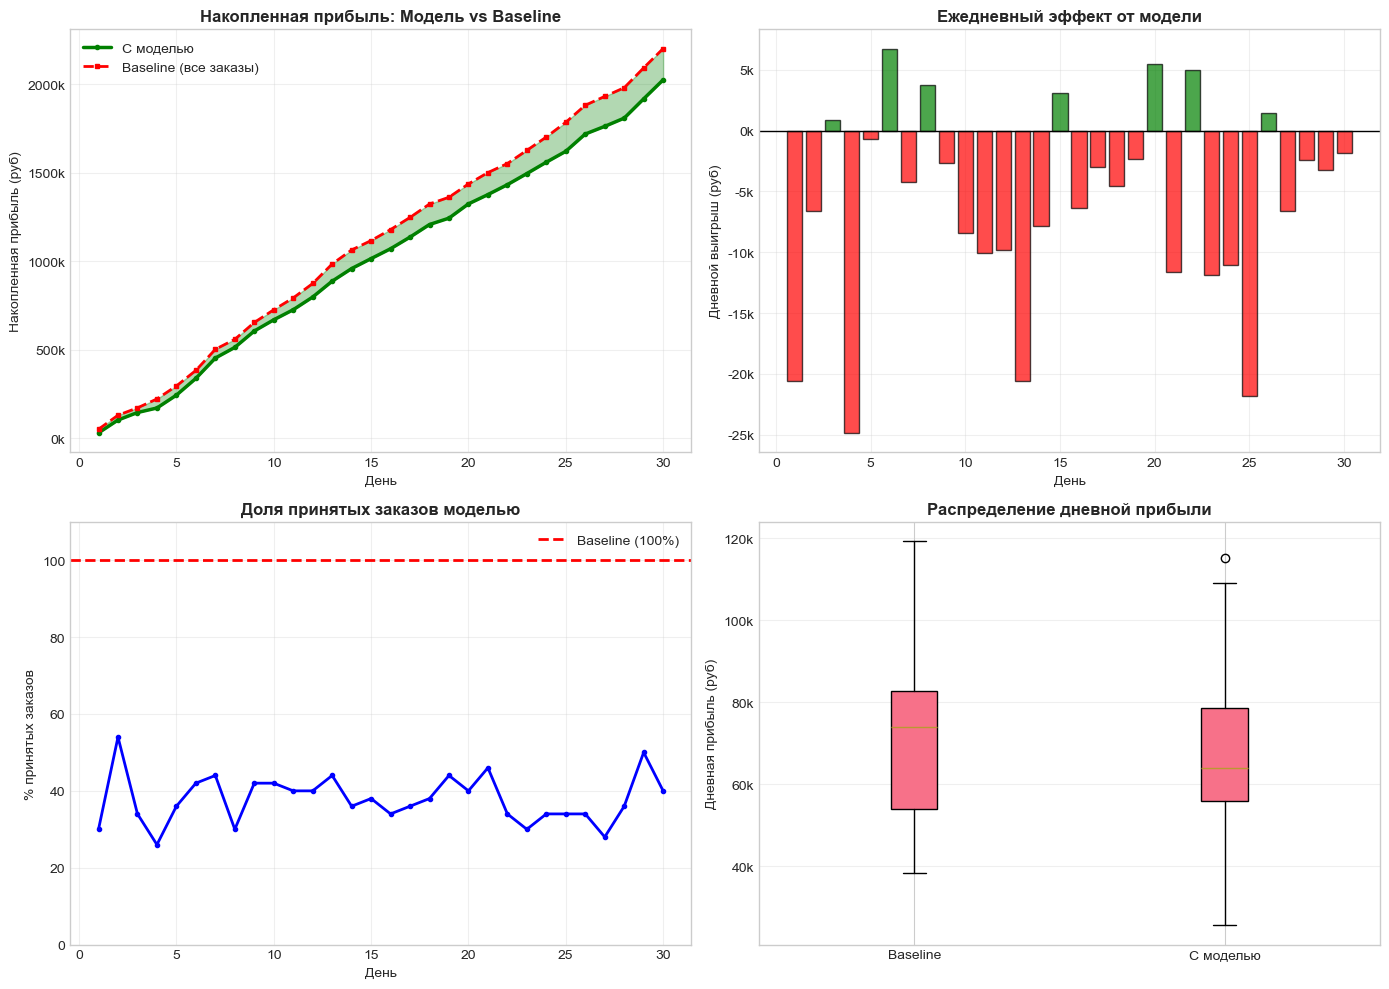

In [3]:
# Генерируем симулированные данные за 30 дней
np.random.seed(42)
days = 30
orders_per_day = 50

simulation_data = []
for day in range(days):
    for order in range(orders_per_day):
        order_amount = np.random.exponential(3000) + 500
        true_buyout_prob = min(0.95, 0.3 + order_amount/20000 + np.random.normal(0, 0.1))
        actual_buyout = 1 if np.random.random() < true_buyout_prob else 0
        
        # Предсказание модели (с некоторой ошибкой)
        predicted_prob = true_buyout_prob + np.random.normal(0, 0.08)
        predicted_prob = max(0.01, min(0.99, predicted_prob))
        
        simulation_data.append({
            'day': day + 1,
            'order_id': day * orders_per_day + order + 1,
            'order_amount': order_amount,
            'true_probability': true_buyout_prob,
            'predicted_probability': predicted_prob,
            'actual_outcome': actual_buyout,
            'model_decision': 1 if predicted_prob >= 0.5 else 0,
            'baseline_decision': 1  # Baseline - принимаем все
        })

sim_df = pd.DataFrame(simulation_data)

# Расчет метрик для каждого дня
daily_metrics = []
for day in range(1, days + 1):
    day_data = sim_df[sim_df['day'] == day]
    
    # Model metrics
    model_accepted = day_data[day_data['model_decision'] == 1]
    model_profit = (model_accepted['order_amount'][model_accepted['actual_outcome'] == 1].sum() - 
                   len(model_accepted[model_accepted['actual_outcome'] == 0]) * 1000)
    
    # Baseline metrics
    baseline_profit = (day_data['order_amount'][day_data['actual_outcome'] == 1].sum() - 
                      len(day_data[day_data['actual_outcome'] == 0]) * 1000)
    
    daily_metrics.append({
        'day': day,
        'model_profit': model_profit,
        'baseline_profit': baseline_profit,
        'model_orders': len(model_accepted),
        'total_orders': len(day_data),
        'model_acceptance_rate': len(model_accepted) / len(day_data) * 100
    })

metrics_df = pd.DataFrame(daily_metrics)
metrics_df['cumulative_model_profit'] = metrics_df['model_profit'].cumsum()
metrics_df['cumulative_baseline_profit'] = metrics_df['baseline_profit'].cumsum()
metrics_df['daily_gain'] = metrics_df['model_profit'] - metrics_df['baseline_profit']
metrics_df['cumulative_gain'] = metrics_df['daily_gain'].cumsum()

print(f"\nРезультаты A/B теста за {days} дней:")
print(f"Всего заказов: {len(sim_df):,}")
print(f"Заказов принято моделью: {sim_df['model_decision'].sum():,} ({sim_df['model_decision'].mean()*100:.1f}%)")
print(f"Прибыль модели: {metrics_df['cumulative_model_profit'].iloc[-1]:,.0f} руб.")
print(f"Прибыль baseline: {metrics_df['cumulative_baseline_profit'].iloc[-1]:,.0f} руб.")
print(f"Эффект от внедрения: {metrics_df['cumulative_gain'].iloc[-1]:,.0f} руб. ({metrics_df['cumulative_gain'].iloc[-1]/abs(metrics_df['cumulative_baseline_profit'].iloc[-1])*100:.1f}%)")

# Визуализация A/B теста
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Cumulative Profit Comparison
axes[0, 0].plot(metrics_df['day'], metrics_df['cumulative_model_profit'], 
                'g-', linewidth=2.5, label='С моделью', marker='o', markersize=3)
axes[0, 0].plot(metrics_df['day'], metrics_df['cumulative_baseline_profit'], 
                'r--', linewidth=2, label='Baseline (все заказы)', marker='s', markersize=3)
axes[0, 0].fill_between(metrics_df['day'], metrics_df['cumulative_baseline_profit'], 
                        metrics_df['cumulative_model_profit'], alpha=0.3, color='green')
axes[0, 0].set_xlabel('День', fontsize=10)
axes[0, 0].set_ylabel('Накопленная прибыль (руб)', fontsize=10)
axes[0, 0].set_title('Накопленная прибыль: Модель vs Baseline', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x/1000:.0f}k"))

# 2. Daily Gain
colors = ['green' if x > 0 else 'red' for x in metrics_df['daily_gain']]
axes[0, 1].bar(metrics_df['day'], metrics_df['daily_gain'], color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].axhline(y=0, color='black', linewidth=1)
axes[0, 1].set_xlabel('День', fontsize=10)
axes[0, 1].set_ylabel('Дневной выигрыш (руб)', fontsize=10)
axes[0, 1].set_title('Ежедневный эффект от модели', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x/1000:.0f}k"))

# 3. Acceptance Rate Over Time
axes[1, 0].plot(metrics_df['day'], metrics_df['model_acceptance_rate'], 
                'b-', linewidth=2, marker='o', markersize=3)
axes[1, 0].axhline(y=100, color='red', linestyle='--', linewidth=2, label='Baseline (100%)')
axes[1, 0].set_xlabel('День', fontsize=10)
axes[1, 0].set_ylabel('% принятых заказов', fontsize=10)
axes[1, 0].set_title('Доля принятых заказов моделью', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(0, 110)

# 4. Profit Distribution
model_profits = []
baseline_profits = []
for day in range(1, days + 1):
    day_data = sim_df[sim_df['day'] == day]
    model_accepted = day_data[day_data['model_decision'] == 1]
    model_profit = (model_accepted['order_amount'][model_accepted['actual_outcome'] == 1].sum() - 
                   len(model_accepted[model_accepted['actual_outcome'] == 0]) * 1000)
    baseline_profit = (day_data['order_amount'][day_data['actual_outcome'] == 1].sum() - 
                      len(day_data[day_data['actual_outcome'] == 0]) * 1000)
    model_profits.append(model_profit)
    baseline_profits.append(baseline_profit)

axes[1, 1].boxplot([baseline_profits, model_profits], labels=['Baseline', 'С моделью'], patch_artist=True)
axes[1, 1].set_ylabel('Дневная прибыль (руб)', fontsize=10)
axes[1, 1].set_title('Распределение дневной прибыли', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x/1000:.0f}k"))

plt.tight_layout()
plt.savefig('scenario2_ab_test.png', dpi=300, bbox_inches='tight')
plt.show()

**Принято заказов: 37.9%**  
На первом графике при оптимуме было 82.9%, а здесь модель приняла только 38% заказов.

**Гипотеза:**  
В этом тесте использовался слишком высокий порог отсечения (например, 0.5 или 0.6), либо модель на тестовых данных ведёт себя иначе.

**Эффект: -176,881 руб. (-8.0%)**  
🔻 Модель принесла меньше денег, чем если бы вы отправляли всё подряд (Baseline).

- Красная линия (Baseline) идёт выше зелёной (Модель) → стратегия «отправлять всё» выгоднее.
> Модель отвергла слишком много хороших заказов **(False Negatives)**.  
> Сэкономили на логистике тех, кто не выкупил  
> Но потеряли гораздо больше прибыли от тех, кто хотел выкупить, но модель их завернула.


## Сценарий 3: What-If Анализ
Оптимизация порога принятия решений для максимизации прибыли.


Оптимальный порог: 0.30
Прибыль при оптимальном пороге: 2,313,472 руб.
Принято заказов: 1,244.0 (82.9%)
Точность (Precision): 51.1%


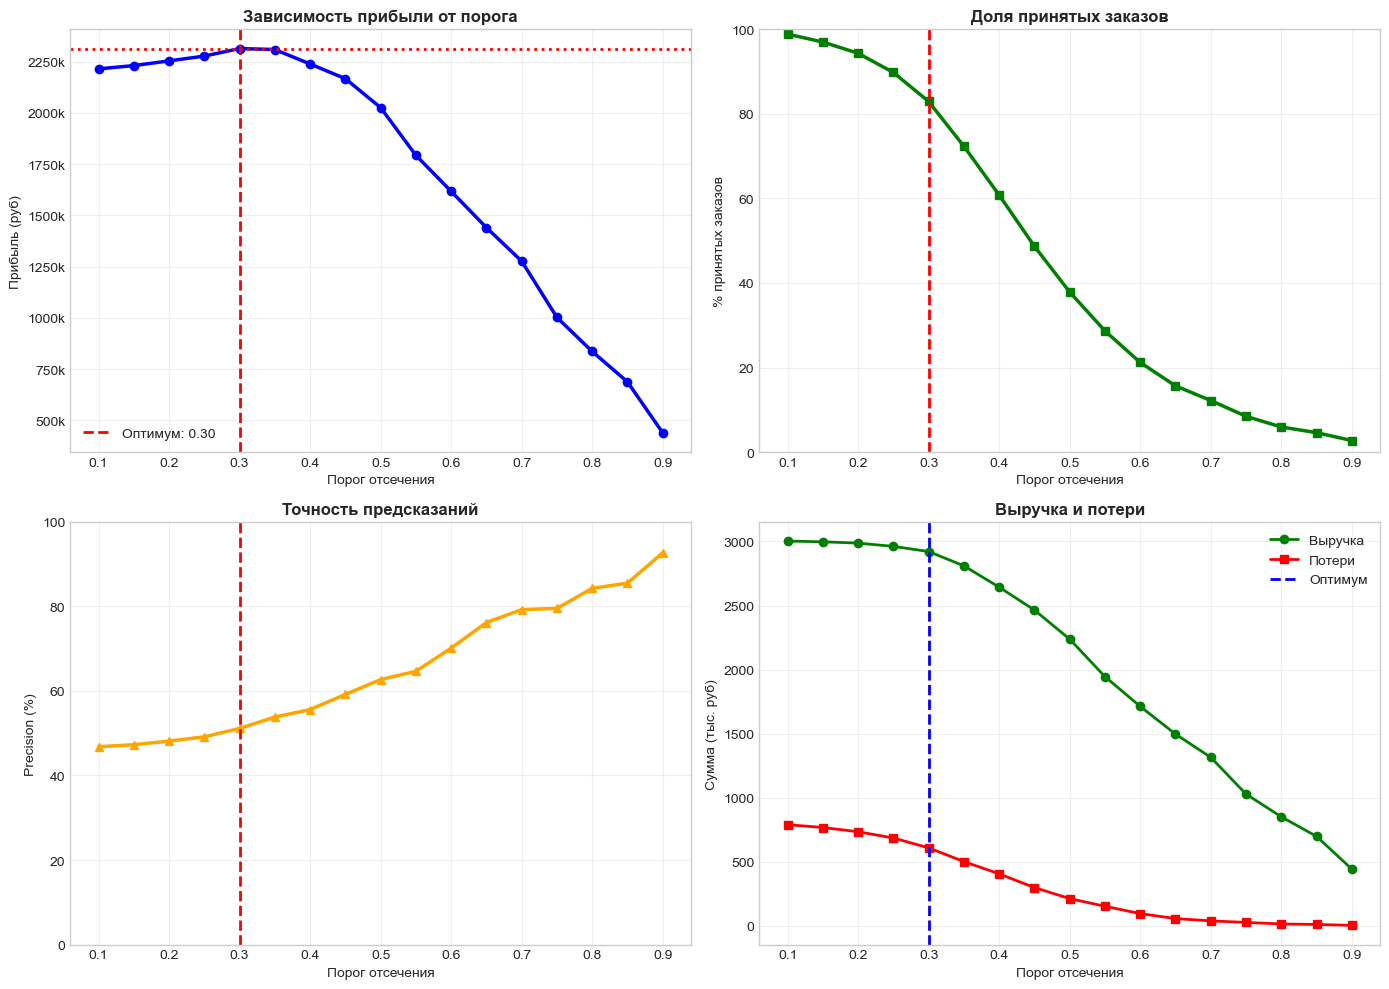

In [4]:
thresholds_analysis = np.arange(0.1, 0.95, 0.05)
analysis_results = []

for thresh in thresholds_analysis:
    sim_df['decision'] = (sim_df['predicted_probability'] >= thresh).astype(int)
    accepted = sim_df[sim_df['decision'] == 1]
    
    total_revenue = accepted['order_amount'][accepted['actual_outcome'] == 1].sum()
    total_losses = len(accepted[accepted['actual_outcome'] == 0]) * 1000
    profit = total_revenue - total_losses
    
    analysis_results.append({
        'threshold': thresh,
        'accepted_orders': len(accepted),
        'acceptance_rate': len(accepted) / len(sim_df) * 100,
        'revenue': total_revenue,
        'losses': total_losses,
        'profit': profit,
        'precision': (accepted['actual_outcome'] == 1).mean() * 100
    })

analysis_df = pd.DataFrame(analysis_results)
best_threshold = analysis_df.loc[analysis_df['profit'].idxmax()]

print(f"\nОптимальный порог: {best_threshold['threshold']:.2f}")
print(f"Прибыль при оптимальном пороге: {best_threshold['profit']:,.0f} руб.")
print(f"Принято заказов: {best_threshold['accepted_orders']:,} ({best_threshold['acceptance_rate']:.1f}%)")
print(f"Точность (Precision): {best_threshold['precision']:.1f}%")

# Визуализация What-If анализа
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Profit vs Threshold
axes[0, 0].plot(analysis_df['threshold'], analysis_df['profit'], 'b-', linewidth=2.5, marker='o')
axes[0, 0].axvline(x=best_threshold['threshold'], color='red', linestyle='--', linewidth=2, 
                   label=f'Оптимум: {best_threshold["threshold"]:.2f}')
axes[0, 0].axhline(y=best_threshold['profit'], color='red', linestyle=':', linewidth=2)
axes[0, 0].set_xlabel('Порог отсечения', fontsize=10)
axes[0, 0].set_ylabel('Прибыль (руб)', fontsize=10)
axes[0, 0].set_title('Зависимость прибыли от порога', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x/1000:.0f}k"))

# 2. Acceptance Rate vs Threshold
axes[0, 1].plot(analysis_df['threshold'], analysis_df['acceptance_rate'], 'g-', linewidth=2.5, marker='s')
axes[0, 1].axvline(x=best_threshold['threshold'], color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Порог отсечения', fontsize=10)
axes[0, 1].set_ylabel('% принятых заказов', fontsize=10)
axes[0, 1].set_title('Доля принятых заказов', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(0, 100)

# 3. Precision vs Threshold
axes[1, 0].plot(analysis_df['threshold'], analysis_df['precision'], 'orange', linewidth=2.5, marker='^')
axes[1, 0].axvline(x=best_threshold['threshold'], color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Порог отсечения', fontsize=10)
axes[1, 0].set_ylabel('Precision (%)', fontsize=10)
axes[1, 0].set_title('Точность предсказаний', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(0, 100)

# 4. Revenue and Losses
axes[1, 1].plot(analysis_df['threshold'], analysis_df['revenue']/1000, 'g-', linewidth=2, label='Выручка', marker='o')
axes[1, 1].plot(analysis_df['threshold'], analysis_df['losses']/1000, 'r-', linewidth=2, label='Потери', marker='s')
axes[1, 1].axvline(x=best_threshold['threshold'], color='blue', linestyle='--', linewidth=2, label='Оптимум')
axes[1, 1].set_xlabel('Порог отсечения', fontsize=10)
axes[1, 1].set_ylabel('Сумма (тыс. руб)', fontsize=10)
axes[1, 1].set_title('Выручка и потери', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scenario3_what_if.png', dpi=300, bbox_inches='tight')
plt.show()

##  Возможные шаги исправления: 
- **Пересмотреть порог отсечения** — снизить с 0.5 до ~0.3, чтобы не терять хорошие заказы.
- **Провести калибровку модели** — убедиться, что предсказанные вероятности соответствуют реальным частотам выкупов.
- **Добавить бизнес-ограничения** — например, всегда принимать заказы с суммой > 10,000 руб., независимо от прогноза.
- **Мониторить False Negatives** — это самая дорогая ошибка: упущенная прибыль от отказанных «хороших» клиентов.